# Phase 1: Environment Setup and Exploratory Data Analysis (EDA)
In this phase, we verify our hardware acceleration (GPU) and explore the `phm_train.csv` dataset. The goal is to understand the class distribution (Personal Health Mentions vs. Non-Personal Health Mentions), analyze text lengths to determine optimal padding later, and identify the most frequent words in each category.

**Note:** The test dataset is strictly isolated and will not be analyzed to prevent data leakage.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from collections import Counter
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords

# Download stopwords if not already present
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Set visualization style
sns.set_theme(style="whitegrid")

# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU Name: NVIDIA GeForce RTX 3050 Laptop GPU


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Ravin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## 1.1 Loading the Training Data and Basic Statistics
Let's load the dataset and look at the overall structure, missing values, and the balance between our two classes: `0` (Non-personal) and `1` (Personal health mention).

In [7]:
# Load the training data
df_train = pd.read_csv('phm_train.csv')

print("--- Dataset Info ---")
print(df_train.info())
print("\n--- First 5 Rows ---")
display(df_train.head())

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9991 entries, 0 to 9990
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   tweet_id  9991 non-null   float64
 1   label     9991 non-null   int64  
 2   tweet     9991 non-null   object 
dtypes: float64(1), int64(1), object(1)
memory usage: 234.3+ KB
None

--- First 5 Rows ---


,tweet_id,label,tweet
0,6.430000e+17,0,user_mention all i can tell you is i have had ...
1,6.440000e+17,0,my doctor told me stop he gave me sum pop i mi...
2,8.150000e+17,1,i take tylenol and i wake up in the middle of ...
3,6.820000e+17,0,i got xans in an advil bottle i dont take them...
4,6.440000e+17,1,mom says i need to stop eating so much bc ive ...


In [8]:
# Check for missing values
print("\n--- Missing Values ---")
print(df_train.isnull().sum())


--- Missing Values ---
tweet_id    0
label       0
tweet       0
dtype: int64


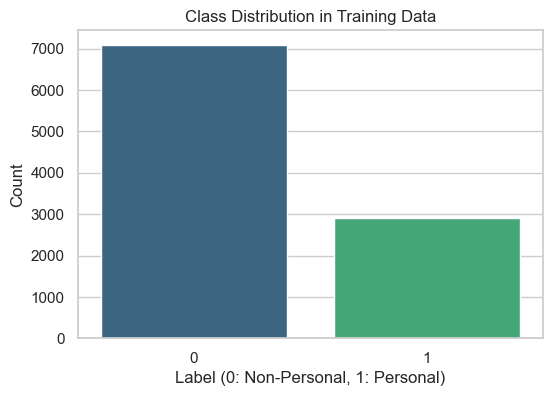


Class Counts:
label
0    70.973876
1    29.026124
Name: proportion, dtype: float64


In [19]:
# Plot Class Distribution
plt.figure(figsize=(6, 4))
# FIX APPLIED HERE: Added hue='label' and legend=False
sns.countplot(data=df_train, x='label', hue='label', palette='viridis', legend=False)
plt.title('Class Distribution in Training Data')
plt.xlabel('Label (0: Non-Personal, 1: Personal)')
plt.ylabel('Count')
plt.show()

print("\nClass Counts:")
print(df_train['label'].value_counts(normalize=True) * 100) # Percentage breakdown

## 1.2 Word Count Analysis
To design an effective LSTM/Bi-LSTM architecture, we need to know how long these tweets are. We will calculate the number of words per tweet for both classes. This will inform our `MAX_SEQUENCE_LENGTH` during the preprocessing phase.

In [11]:
# Calculate word count for each tweet
df_train['word_count'] = df_train['tweet'].apply(lambda x: len(str(x).split()))

print("--- Overall Word Count Statistics ---")
print(df_train['word_count'].describe())

--- Overall Word Count Statistics ---
count    9991.000000
mean       15.567010
std         6.233004
min         5.000000
25%        10.000000
50%        15.000000
75%        21.000000
max        32.000000
Name: word_count, dtype: float64


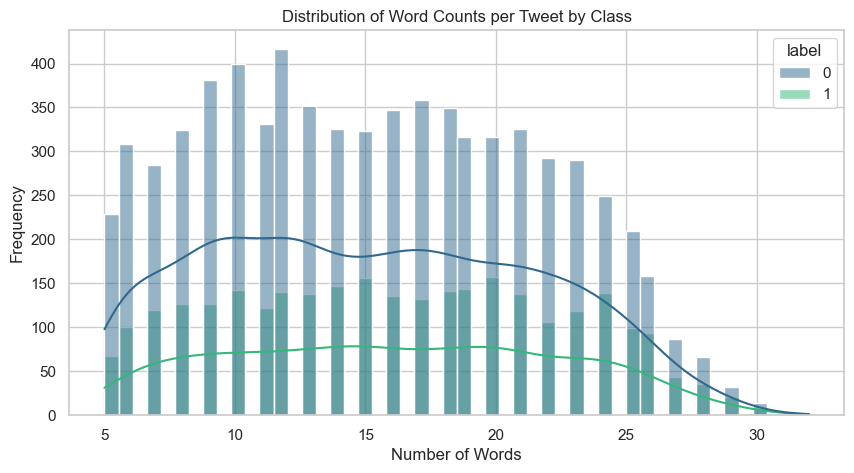

In [12]:
# Plot Word Count Distribution by Class
plt.figure(figsize=(10, 5))
sns.histplot(data=df_train, x='word_count', hue='label', bins=50, kde=True, palette='viridis')
plt.title('Distribution of Word Counts per Tweet by Class')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()

In [16]:
# Separate dataframes for each class for deeper text analysis
df_class_0 = df_train[df_train['label'] == 0]
df_class_1 = df_train[df_train['label'] == 1]

print(f"\nAverage word count for Label 0: {df_class_0['word_count'].mean():.2f}")
print(f"Average word count for Label 1: {df_class_1['word_count'].mean():.2f}")


Average word count for Label 0: 15.35
Average word count for Label 1: 16.10


## 1.3 Vocabulary and Common Words Analysis
We will analyze the most frequent words in each class, excluding standard English stopwords. This helps us understand the semantic differences between the classes and verifies if our future embedding strategy needs domain-specific vocabularies.

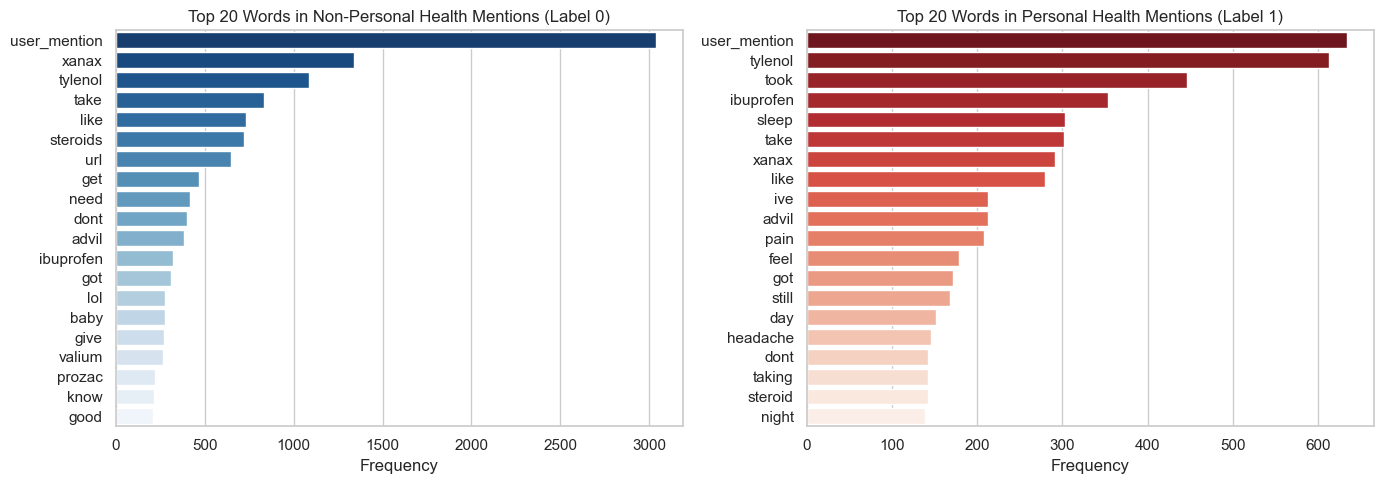

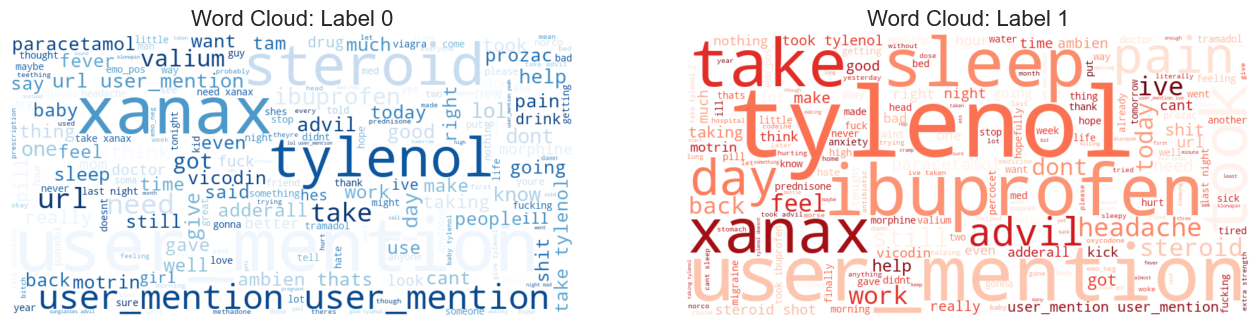

In [18]:
def get_most_common_words(text_series, num_words=20):
    # Combine all text, split into words, and filter stopwords
    all_words = ' '.join(text_series.astype(str)).lower().split()
    filtered_words = [word for word in all_words if word not in stop_words and len(word) > 2]
    word_freq = Counter(filtered_words)
    return word_freq.most_common(num_words), ' '.join(filtered_words)

# Get common words for both classes
common_0, text_0 = get_most_common_words(df_class_0['tweet'])
common_1, text_1 = get_most_common_words(df_class_1['tweet'])

# Extract X and Y data for Label 0
x_0 = [val[1] for val in common_0]
y_0 = [val[0] for val in common_0]

# Extract X and Y data for Label 1
x_1 = [val[1] for val in common_1]
y_1 = [val[0] for val in common_1]

# Plot top words for Label 0
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
# FIX APPLIED HERE: Added hue=y_0 and legend=False
sns.barplot(x=x_0, y=y_0, hue=y_0, palette='Blues_r', legend=False)
plt.title('Top 20 Words in Non-Personal Health Mentions (Label 0)')
plt.xlabel('Frequency')

# Plot top words for Label 1
plt.subplot(1, 2, 2)
# FIX APPLIED HERE: Added hue=y_1 and legend=False
sns.barplot(x=x_1, y=y_1, hue=y_1, palette='Reds_r', legend=False)
plt.title('Top 20 Words in Personal Health Mentions (Label 1)')
plt.xlabel('Frequency')
plt.tight_layout()
plt.show()

# Generate Word Clouds
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

wc_0 = WordCloud(width=800, height=400, background_color='white', colormap='Blues').generate(text_0)
ax1.imshow(wc_0, interpolation='bilinear')
ax1.set_title('Word Cloud: Label 0', fontsize=16)
ax1.axis('off')

wc_1 = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(text_1)
ax2.imshow(wc_1, interpolation='bilinear')
ax2.set_title('Word Cloud: Label 1', fontsize=16)
ax2.axis('off')

plt.show()

# Phase 2: Text Preprocessing and PyTorch Dataset Setup
In this phase, we clean the text while carefully preserving contextual keywords like `user_mention` and `url`. Then, we build a vocabulary, tokenize the text (converting words to numbers), and create a custom PyTorch `Dataset`. Finally, we prepare a 5-Fold Stratified Cross-Validation split to ensure our model trains robustly on this imbalanced dataset.

## Python Code (Text Cleaning & Vocabulary Building)

In [20]:
import re
from collections import Counter
from sklearn.model_selection import StratifiedKFold
from torch.utils.data import Dataset, DataLoader

# 1. Custom Text Cleaner
def clean_tweet(text):
    text = str(text).lower()
    # We keep letters, numbers, and underscores (to preserve user_mention)
    # Everything else (commas, periods, special chars) is removed
    text = re.sub(r'[^a-z0-9_ ]', '', text)
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply cleaning to the training data
df_train['clean_tweet'] = df_train['tweet'].apply(clean_tweet)

# 2. Build Vocabulary
# We need to map every unique word to an integer index
all_words = ' '.join(df_train['clean_tweet']).split()
word_counts = Counter(all_words)

# Keep words that appear at least 2 times to reduce noise (rare typos)
min_freq = 2
vocab_words = [word for word, count in word_counts.items() if count >= min_freq]

# Create dictionaries mapping Word <-> Index
# Index 0 is reserved for Padding (<PAD>), Index 1 is for Unknown words (<UNK>)
word2idx = {'<PAD>': 0, '<UNK>': 1}
for idx, word in enumerate(vocab_words, start=2):
    word2idx[word] = idx

idx2word = {idx: word for word, idx in word2idx.items()}
VOCAB_SIZE = len(word2idx)

print(f"Original vocabulary size: {len(word_counts)}")
print(f"Reduced vocabulary size (min_freq={min_freq}): {VOCAB_SIZE}")

Original vocabulary size: 12918
Reduced vocabulary size (min_freq=2): 5442


## Python Code (Tokenization and PyTorch Dataset)

In [21]:
# Set the maximum length of a tweet (based on our EDA earlier, 40 is very safe)
MAX_LEN = 40

# Function to convert a text string into a list of padded integers
def encode_tweet(text, vocab, max_len):
    tokens = text.split()
    # Convert to indices, use <UNK> (1) if word is not in vocab
    encoded = [vocab.get(word, 1) for word in tokens]
    
    # Pad or Truncate
    if len(encoded) < max_len:
        # Pad with 0s at the end
        encoded = encoded + [0] * (max_len - len(encoded))
    else:
        # Truncate to max_len
        encoded = encoded[:max_len]
        
    return encoded

# Create Custom PyTorch Dataset
class TweetDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len):
        self.texts = texts
        self.labels = labels
        self.vocab = vocab
        self.max_len = max_len
        
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = self.texts.iloc[idx]
        label = self.labels.iloc[idx]
        
        # Encode text
        encoded_text = encode_tweet(text, self.vocab, self.max_len)
        
        # Convert to PyTorch Tensors
        x_tensor = torch.tensor(encoded_text, dtype=torch.long)
        y_tensor = torch.tensor(label, dtype=torch.float32) # float32 for binary cross entropy
        
        return x_tensor, y_tensor

# Quick test to ensure the Dataset works
sample_dataset = TweetDataset(df_train['clean_tweet'], df_train['label'], word2idx, MAX_LEN)
sample_x, sample_y = sample_dataset[0]
print("--- Dataset Output Test ---")
print(f"Original Text: {df_train['clean_tweet'].iloc[0]}")
print(f"Encoded Tensor: {sample_x}")
print(f"Label Tensor: {sample_y}")

--- Dataset Output Test ---
Original Text: user_mention all i can tell you is i have had few relapses on it it is not a cure i hear if you dont test for the jc virus tysabri is good
Encoded Tensor: tensor([ 2,  3,  4,  5,  6,  7,  8,  4,  9, 10, 11, 12, 13, 14, 14,  8, 15, 16,
        17,  4, 18, 19,  7, 20, 21, 22, 23, 24, 25, 26,  8, 27,  0,  0,  0,  0,
         0,  0,  0,  0])
Label Tensor: 0.0


## Python Code (5-Fold Setup & Class Weights)

In [22]:
# 3. Prepare 5-Fold Stratified Cross Validation
# Stratified ensures the 71/29 class imbalance is maintained in every fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Extract inputs and targets
X_data = df_train['clean_tweet']
y_data = df_train['label']

# 4. Calculate Class Weights for the Loss Function
# Since Class 0 is ~71% and Class 1 is ~29%, we need to tell the model to pay more attention to Class 1.
class_0_count = len(df_train[df_train['label'] == 0])
class_1_count = len(df_train[df_train['label'] == 1])
total_count = len(df_train)

weight_for_0 = (1 / class_0_count) * (total_count / 2.0)
weight_for_1 = (1 / class_1_count) * (total_count / 2.0)

# We pass this positive weight to PyTorch's BCEWithLogitsLoss later
pos_weight = torch.tensor([weight_for_1 / weight_for_0]).to(device)

print(f"Calculated Positive Class Weight (Multiplier for Label 1): {pos_weight.item():.4f}")
print("5-Fold Cross Validation is ready for the training loop.")

Calculated Positive Class Weight (Multiplier for Label 1): 2.4452
5-Fold Cross Validation is ready for the training loop.


# Phase 3: Building the LSTM and Bi-LSTM Models
Here we define the neural network architectures using PyTorch. Both models will start with an `nn.Embedding` layer which will learn the task-specific embeddings from scratch based on our training data. 

We will define a single class where `bidirectional=True` can be toggled to easily switch between a standard LSTM and a Bi-LSTM.

In [23]:
import torch.nn as nn

class TweetClassifierLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, n_layers, 
                 bidirectional, dropout_rate):
        super(TweetClassifierLSTM, self).__init__()
        
        # 1. Embedding Layer: This learns the relationships between words
        # padding_idx=0 ensures the <PAD> token doesn't affect gradients
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        
        # 2. LSTM Layer
        self.lstm = nn.LSTM(embedding_dim, 
                            hidden_dim, 
                            num_layers=n_layers, 
                            bidirectional=bidirectional, 
                            dropout=dropout_rate if n_layers > 1 else 0,
                            batch_first=True)
        
        # 3. Dropout for regularization (prevents overfitting)
        self.dropout = nn.Dropout(dropout_rate)
        
        # 4. Fully Connected (Linear) Layer
        # If bidirectional, the hidden state is twice as large
        self.fc = nn.Linear(hidden_dim * 2 if bidirectional else hidden_dim, output_dim)
        
    def forward(self, text):
        # text shape: [batch size, sentence length]
        
        # Pass text through embedding layer
        # embedded shape: [batch size, sentence length, embedding dim]
        embedded = self.dropout(self.embedding(text))
        
        # Pass embeddings through LSTM
        # output shape: [batch size, sentence length, hidden dim * num directions]
        # hidden shape: [num layers * num directions, batch size, hidden dim]
        output, (hidden, cell) = self.lstm(embedded)
        
        # Extract the final hidden state
        if self.lstm.bidirectional:
            # Concat the final forward and backward hidden states
            hidden = self.dropout(torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1))
        else:
            hidden = self.dropout(hidden[-1,:,:])
            
        # hidden shape: [batch size, hidden dim * num directions]
        
        # Pass through the linear layer
        return self.fc(hidden)

print("LSTM / Bi-LSTM Model Class defined successfully!")

LSTM / Bi-LSTM Model Class defined successfully!


# Phase 4: Advanced Hyperparameter Tuning with Optuna
In this phase, we use Optuna to automatically discover the best hyperparameters. We implement **5-Fold Cross-Validation** to ensure robust evaluation, **Automatic Mixed Precision (AMP)** for faster GPU training, and optimize strictly for the **F1-Score** to combat our class imbalance.

## Python Code (Helper Functions & Metrics)

In [ ]:
import torch.optim as optim
from sklearn.metrics import f1_score, accuracy_score
from torch.cuda.amp import autocast, GradScaler
import optuna
import copy

# Advanced Loss Function for Imbalanced Datasets
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, logits=True, reduce=True):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.bce_with_logits = nn.BCEWithLogitsLoss(reduction='none')

    def forward(self, inputs, targets):
        BCE_loss = self.bce_with_logits(inputs, targets)
        pt = torch.exp(-BCE_loss)
        F_loss = self.alpha * (1-pt)**self.gamma * BCE_loss
        return torch.mean(F_loss)

print("Advanced Metrics and Focal Loss ready.")

ModuleNotFoundError: No module named 'optuna'